In [2]:
import torch
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor
from torch.utils.data import Dataset
import os
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import random
from torch.utils.data import random_split
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import lightning as pl
import torchmetrics
import comet_ml
import os
from lightning.pytorch import Trainer, seed_everything
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from comet_ml import Experiment
import pandas as pd
import numpy as np
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
from mediapipe_handcrop import MediapipeHandCrop
from tqdm import tqdm

## CUDA SETUP

In [3]:
def setup_device():
    if torch.cuda.is_available():
        device = torch.device('cuda')
        torch.set_default_dtype(torch.float32)
    else:
        device = torch.device('cpu')
        torch.set_default_dtype(torch.float32)
    return device

device = setup_device()
print(f"Using {device} device")

# Set random seed for reproducibility
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

Using cuda device


## CREATE TRAIN AND TEST CSV FILES

In [4]:
def average_brightness(image):
    # Convert to CSV
    hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # # Extracting brightness channel (V)
    brightness_channel = hsv_image[:, :, 2]

    average_brightness = np.mean(brightness_channel)
    if average_brightness > 50: 
        return True
    
    else: return False

In [ ]:
train_pth = r"C:\Users\Hyperbook\Desktop\STUDIA\DLF3\DLF-sign_letters_classification\new_dataset\train"
test_pth = r"C:\Users\Hyperbook\Desktop\STUDIA\DLF3\DLF-sign_letters_classification\new_dataset\test"

import pandas as pd
import os
import json
from tqdm import tqdm
import cv2
import numpy as np
from PIL import Image

mediapipe_validator = MediapipeHandCrop(include_characteristic_vectors=True)

def validate_dataset_with_mediapipe(dataset_path, csv_file_path, new_dir):
    data = []
    classes_to_ignore = ["del", "nothing", "space"]
    index = 0

    for class_name in os.listdir(dataset_path):
        if class_name not in classes_to_ignore:
            # Create a directory for new validated class images
            new_class_path = os.path.join(new_dir, class_name)
            os.makedirs(new_class_path, exist_ok=True)

            class_index = ord(class_name) - 65
            count = 0

            for image_name in tqdm(os.listdir(os.path.join(dataset_path, class_name))):
                image_path = os.path.join(dataset_path, class_name, image_name)

                # Validate image with Mediapipe and brightness
                try:
                    result = mediapipe_validator(image_path)
                    if result is None:
                        continue
                    cropped_image, characteristic_vectors = result

                    # Check brightness and size
                    if average_brightness(np.array(cropped_image)) and cropped_image.size > (60, 60):
                        # Save the cropped image
                        new_image_path = os.path.join(new_class_path, image_name)
                        cropped_image = np.array(cropped_image)
                        cv2.imwrite(new_image_path, cropped_image)

                        # Append to the dataset
                        data.append({
                            "image_path": new_image_path,
                            "characteristic_vectors": json.dumps(characteristic_vectors),  # Serialize to JSON
                            "class_name": class_name,
                            "class_index": class_index,
                            "index": index
                        })
                        index += 1
                        count += 1

                except Exception as e:
                    print(f"Error processing {image_path}: {e}")
                    continue
                # break

            print(f"Saved {count} images from class {class_name}")

    # Save dataset to a CSV file
    df = pd.DataFrame(data)
    df.to_csv(csv_file_path, index=False)


In [ ]:
# Create csv and dir
validate_dataset_with_mediapipe(train_pth, 
                                csv_file_path = r"newest_dataset/validated_train_csv.csv",
                                new_dir = r"newest_dataset/validated_train")

100%|██████████| 8458/8458 [03:00<00:00, 46.92it/s]


Saved 3725 images from class A


100%|██████████| 8309/8309 [03:10<00:00, 43.67it/s]


Saved 5874 images from class B


100%|██████████| 8146/8146 [02:49<00:00, 48.13it/s]


...

Saved 4644 images from class X


100%|██████████| 8178/8178 [03:11<00:00, 42.81it/s]


Saved 5895 images from class Y


100%|██████████| 7410/7410 [02:49<00:00, 43.79it/s]


Saved 5029 images from class Z


In [ ]:
validate_dataset_with_mediapipe(test_pth, 
                                csv_file_path = r"newest_dataset/validated_test_csv.csv",
                                new_dir = r"newest_dataset/validated_test")

100%|██████████| 30/30 [00:00<00:00, 32.92it/s]


Saved 14 images from class A


100%|██████████| 30/30 [00:00<00:00, 33.81it/s]


Saved 29 images from class B


100%|██████████| 30/30 [00:00<00:00, 33.54it/s]


...

Saved 26 images from class X


100%|██████████| 30/30 [00:00<00:00, 33.44it/s]


Saved 29 images from class Y


100%|██████████| 30/30 [00:00<00:00, 33.66it/s]

Saved 30 images from class Z


## DATASET

In [4]:
import ast

transform = transforms.Compose([
    transforms.Resize((64,64)),
    # transforms.CenterCrop((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Values calculated from the ImageNet dataset
])

class Dataset(Dataset):
    def __init__(self, root_dir, csv_file, transform=None):
        self.root_dir = root_dir
        self.csv_file = csv_file
        self.transform = transform
        self.df = pd.read_csv(self.csv_file)
        self.classes = sorted(np.unique(self.df["class_index"]))
        self.class_names = sorted(np.unique(self.df["class_name"]))
        
    def __len__(self):
        dataset_len = len(self.df)
        return dataset_len
    
    def __getitem__(self, index):
        if index >= len(self):
            raise IndexError("Index out of bounds")
        
        label = self.df.loc[index, "class_index"]
        image_path = self.df.loc[index, "image_path"]
        characteristic_vectors_str = self.df.loc[index, "characteristic_vectors"]

        # Konwersja wektorów charakterystycznych
        characteristic_vectors = ast.literal_eval(characteristic_vectors_str)  
        characteristic_vectors = np.array(characteristic_vectors, dtype=np.float32)

        # Ładowanie obrazu
        image = cv2.imread(image_path, cv2.IMREAD_COLOR)
        if image is None:
            raise FileNotFoundError(f"Image not found: {image_path}")
        
        # Konwersja do RGB
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Przekształcenia obrazu
        if self.transform:
            image = self.transform(Image.fromarray(image))

        # Skalowanie wektorów
        original_height, original_width = 64, 64  # Docelowe wymiary po transformacji
        characteristic_vectors[:, 0] *= (image.shape[2] / original_width)
        characteristic_vectors[:, 1] *= (image.shape[1] / original_height)

        return image, label, characteristic_vectors
        

In [5]:
# Train dataset and dataloader initialization
train_dataset = Dataset(root_dir="./newest_dataset/validated_train/",
                        csv_file= "./newest_dataset/validated_train_csv.csv",
                        transform=transform)

Dataset len:
132881

Dataset classes:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]

Random image from dataset:

Image size:
torch.Size([3, 64, 64])


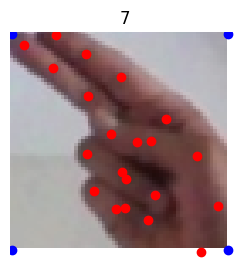

Characteristic vectors: 
[[56.02211    64.54266   ]
 [60.85528    50.80657   ]
 [54.802734   36.2457    ]
 [41.107754   31.817934  ]
 [29.425692   29.618126  ]
 [45.512276   25.218761  ]
 [32.19732    12.778829  ]
 [21.87083     6.071207  ]
 [12.9588175   0.27632493]
 [37.163982   31.938772  ]
 [22.646368   18.366749  ]
 [12.066154   10.177934  ]
 [ 3.602984    3.213813  ]
 [32.592422   41.024277  ]
 [22.36433    35.455063  ]
 [33.73319    42.883636  ]
 [42.398926   47.796352  ]
 [30.737562   51.888042  ]
 [24.279572   46.560955  ]
 [33.41823    51.423237  ]
 [40.38418    55.090122  ]]


In [6]:
# Sanity check
print("Dataset len:")
print(len(train_dataset))

print("\nDataset classes:")
print(train_dataset.classes)

print("\nRandom image from dataset:")
img, label, characteristic_vectors = train_dataset[random.randint(0, len(train_dataset)-1)]
image = img.permute(1, 2, 0).numpy()  # [C, H, W] -> [H, W, C]

print('\nImage size:')
print(img.shape)

# Denormalizing (there was normalization in transform)
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
image = image * std + mean
image = image.clip(0, 1)

plt.figure(figsize=(3,3))
plt.imshow(image)
plt.scatter(characteristic_vectors[:, 0], characteristic_vectors[:, 1], c='red')
plt.scatter([0, 0, img.shape[2], img.shape[2]], [0, img.shape[1], img.shape[1], 0], c="blue")  

plt.axis("off")
plt.title(label)
plt.show()

print("Characteristic vectors: ")
print(characteristic_vectors)


In [7]:
# Train dataset and dataloader initialization
test_dataset = Dataset(root_dir="./newest_dataset/validated_test/",
                        csv_file= "./newest_dataset/validated_test_csv.csv",
                        transform=transform)

Dataset len:
674

Dataset classes:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]

Random image from dataset:

Image size:
torch.Size([3, 64, 64])


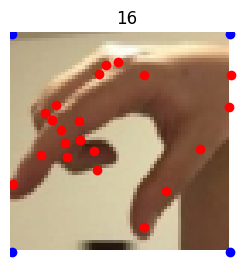

Characteristic vectors: 
[[64.50535    12.105292  ]
 [63.88602    21.515816  ]
 [55.268185   33.717545  ]
 [45.186985   45.99512   ]
 [38.710358   56.54359   ]
 [38.865818   12.096409  ]
 [19.675722   25.521088  ]
 [ 8.491266   35.655785  ]
 [ 0.41333959 44.102856  ]
 [31.296934    8.295915  ]
 [11.684626   25.306446  ]
 [16.14616    36.205982  ]
 [24.925482   40.015152  ]
 [27.537605    9.108144  ]
 [ 9.798894   23.231392  ]
 [15.731104   31.895132  ]
 [24.180443   34.29977   ]
 [25.609276   11.884642  ]
 [12.916764   20.902912  ]
 [14.541105   28.217836  ]
 [20.06882    31.144981  ]]


In [8]:
# Sanity check
print("Dataset len:")
print(len(test_dataset))

print("\nDataset classes:")
print(test_dataset.classes)

print("\nRandom image from dataset:")
img, label, characteristic_vectors = test_dataset[random.randint(0, len(test_dataset)-1)]
image = img.permute(1, 2, 0).numpy()  # [C, H, W] -> [H, W, C]
print('\nImage size:')
print(img.shape)

# Denormalizing (there was normalization in transform)
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
image = image * std + mean
image = image.clip(0, 1)

plt.figure(figsize=(3,3))
plt.imshow(image)
plt.scatter(characteristic_vectors[:, 0], characteristic_vectors[:, 1], c='red')
plt.scatter([0, 0, img.shape[2], img.shape[2]], [0, img.shape[1], img.shape[1], 0], c="blue")  # Granice prostokąta

plt.axis("off")
plt.title(label)
plt.show()

print("Characteristic vectors: ")
print(characteristic_vectors)

## SPLITING DATA INTO TRAINING AND VALIDATION DATASETS

In [20]:
train_len = round(0.8 * len(train_dataset))
val_len = len(train_dataset) - train_len
train_len, val_len, train_len + val_len == len(train_dataset)

(106305, 26576, True)

In [21]:
train_dataset_, val_dataset = random_split(train_dataset, [train_len, val_len])

In [22]:
# Sanity check once more

print(f"Number of training samples: {len(train_dataset_)}")
print(f"Number of validation samples: {len(val_dataset)}")
print(f"Number of train classes: {len(train_dataset_.dataset.classes)}")
print(f"Number of val classes: {len(val_dataset.dataset.classes)}")
print(f"Number of test samples: {len(test_dataset)}") 


Number of training samples: 106305
Number of validation samples: 26576
Number of train classes: 26
Number of val classes: 26
Number of test samples: 674


In [23]:
print(f"Train dataset classes: {train_dataset.classes}")
print(f"Validation dataset classes: {train_dataset.classes}")

Train dataset classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]
Validation dataset classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]


## DATALOADERS

In [24]:
import os
num_workers = os.cpu_count()
print(f"Suggested num_workers: {num_workers}")

Suggested num_workers: 24


In [25]:
import torch.multiprocessing as mp
mp.set_start_method('spawn', force=True)  # Use 'spawn' to safely initialize workers

train_dataloader = DataLoader(train_dataset_, 
                              batch_size=32, 
                              shuffle=True,
                              pin_memory=True)

val_dataloader = DataLoader(val_dataset,
                            batch_size=32,
                            shuffle=False,
                            pin_memory=True)

test_dataloader = DataLoader(test_dataset, 
                             batch_size=32, 
                             shuffle=False,
                             pin_memory=True)


In [26]:
# Sanity check
def loader_sanity_check(loader):
    for batch_idx, (data, labels, characteristic_vectors) in enumerate(loader):
        print(f"Batch nr: {batch_idx}")
        print(f"Batch size: {data.shape[0]}")
        print(f"Data shape: {data.shape}")
        print(f"Image shape: {data[0].shape}")
        print(f"Characteristic vectors shape: {len(characteristic_vectors)}")
        print(f"Characteristic vectors: {characteristic_vectors}")
        print(f"Classes: {labels}")
        print(f"Num classes: {len(labels)}")
        break

In [27]:
loader_sanity_check(train_dataloader)

Batch nr: 0
Batch size: 32
Data shape: torch.Size([32, 3, 64, 64])
Image shape: torch.Size([3, 64, 64])
Characteristic vectors shape: 32
Characteristic vectors: tensor([[[49.7347, 64.7619],
         [60.4390, 51.9346],
         [62.5659, 32.7257],
         ...,
         [11.5949, 48.5856],
         [20.2919, 55.0631],
         [27.8830, 60.4392]],

        [[55.5777, 55.5056],
         [64.6466, 44.6321],
         [65.6644, 27.4384],
         ...,
         [14.7426, 26.4632],
         [ 6.6903, 20.0722],
         [ 0.4593, 14.6883]],

        [[33.1521, 64.9137],
         [42.1419, 57.6430],
         [44.8196, 45.6318],
         ...,
         [21.7162, 37.8653],
         [25.6153, 44.0508],
         [27.0782, 50.0656]],

        ...,

        [[24.9139, 64.2475],
         [42.7581, 53.9726],
         [56.4863, 33.9703],
         ...,
         [ 7.6526, 24.1294],
         [10.2053, 37.0565],
         [12.9956, 46.2990]],

        [[12.3524, 57.3314],
         [29.5941, 53.3248],
       

In [28]:
loader_sanity_check(val_dataloader)

Batch nr: 0
Batch size: 32
Data shape: torch.Size([32, 3, 64, 64])
Image shape: torch.Size([3, 64, 64])
Characteristic vectors shape: 32
Characteristic vectors: tensor([[[36.4634, 64.1961],
         [28.4484, 59.4777],
         [25.3046, 48.6481],
         ...,
         [45.8976, 36.9146],
         [42.5650, 41.1631],
         [39.7497, 45.5458]],

        [[32.2286, 65.6383],
         [42.4070, 56.1283],
         [44.5094, 44.1125],
         ...,
         [20.8668, 37.5404],
         [23.9813, 43.8273],
         [25.7322, 49.8573]],

        [[57.9535, 59.7798],
         [65.3548, 46.1118],
         [64.3412, 27.2035],
         ...,
         [20.8075, 54.0292],
         [31.8102, 58.5609],
         [39.5575, 60.2829]],

        ...,

        [[ 2.9616, 59.7202],
         [19.1263, 64.0348],
         [34.0507, 53.5925],
         ...,
         [28.3303, 14.6060],
         [34.3532,  8.6517],
         [39.5879,  2.9231]],

        [[38.7747, 46.0718],
         [56.0613, 44.7954],
       

In [29]:
loader_sanity_check(test_dataloader)

Batch nr: 0
Batch size: 32
Data shape: torch.Size([32, 3, 64, 64])
Image shape: torch.Size([3, 64, 64])
Characteristic vectors shape: 32
Characteristic vectors: tensor([[[ 7.1326, 62.4355],
         [28.6861, 60.4777],
         [49.9131, 45.6650],
         ...,
         [ 6.2890, 10.9291],
         [ 7.8201, 26.7674],
         [ 8.3716, 37.7560]],

        [[ 5.8576, 57.6342],
         [26.7703, 59.6616],
         [48.0776, 40.9094],
         ...,
         [ 7.2527, 10.1613],
         [ 6.5580, 26.1311],
         [ 5.7348, 36.1081]],

        [[ 5.8957, 60.1201],
         [27.1208, 59.0330],
         [47.5304, 42.6835],
         ...,
         [ 6.6615, 11.1107],
         [ 6.4246, 27.3819],
         [ 6.0614, 37.7908]],

        ...,

        [[26.5988, 64.1663],
         [36.5560, 59.6189],
         [43.4383, 47.9348],
         ...,
         [22.0566, 23.1919],
         [23.1683, 17.1042],
         [24.1680, 11.5004]],

        [[26.0426, 64.0471],
         [36.3126, 59.0488],
       

## COMET_ML SETUP

In [30]:
from comet_ml import Experiment

# Initialize Comet.ml experiment
experiment = Experiment(
    api_key=os.getenv("COMET_API_KEY"),
    project_name="DLF-sign_letters_classification",
)

experiment.set_name("Multimodal model resnet")

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: torch.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/ziemmi13/dlf-sign-letters-classification/60bfba9d675b44d2a0bbb2739b4ee9d7



## Define helper functions to logs gradients and weights

In [31]:
def to_numpy(x):
    return x.detach().numpy()


def update_gradient_map(model, gradmap):
    for name, layer in zip(model._modules, model.children()):
        if "activ" in name:
            continue

        if not hasattr(layer, "weight"):
            continue

        wname = "%s/%s.%s" % ("gradient", name, "weight")
        bname = "%s/%s.%s" % ("gradient", name, "bias")

        gradmap.setdefault(wname, 0)
        gradmap.setdefault(bname, 0)

        gradmap[wname] += layer.weight.grad
        gradmap[bname] += layer.bias.grad

    return gradmap


def log_gradients(gradmap, step):
    for k, v in gradmap.items():
        experiment.log_histogram_3d(to_numpy(v), name=k, step=step)


def log_weights(model, step):
    for name, layer in zip(model._modules, model.children()):
        if "activ" in name:
            continue

        if not hasattr(layer, "weight"):
            continue

        wname = "%s.%s" % (name, "weight")
        bname = "%s.%s" % (name, "bias")

        experiment.log_histogram_3d(to_numpy(layer.weight), name=wname, step=step)
        experiment.log_histogram_3d(to_numpy(layer.bias), name=bname, step=step)

## MULTIMODAL MODEL

In [36]:
import torch
import torch.nn as nn
import torchvision.models as models

class MultimodalModel(nn.Module):
    def __init__(self, num_classes, num_landmarks=21):
        super().__init__()
       
        # Image processing branch (ResNet50)
        self.base_model = models.resnet50(pretrained=True)
        self.base_model = nn.Sequential(*list(self.base_model.children())[:-1])
       
        # Freeze feature extractor
        for param in self.base_model.parameters():
            param.requires_grad = False
           
        # Image branch fully connected layers
        self.fc_image = nn.Sequential(
            nn.Linear(2048, 1024),
            nn.ReLU(),
            nn.LayerNorm(1024),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.LayerNorm(512),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.LayerNorm(256),
            nn.Dropout(0.3)
        )
       
        # Landmark processing branch
        self.fc_landmarks = nn.Sequential(
            nn.Linear(num_landmarks * 2, 128),
            nn.ReLU(),
            nn.LayerNorm(128),
            nn.Dropout(0.2),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.LayerNorm(256),
            nn.Dropout(0.3)
        )
       
        # Combined classifier
        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.LayerNorm(256),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
       
    def forward(self, images, landmarks):
        # Process images through ResNet
        x = self.base_model(images)
        x = torch.flatten(x, 1)
        image_features = self.fc_image(x)
       
        # Process landmark features
        batch_size = landmarks.size(0)
        landmarks_flat = landmarks.view(batch_size, -1)
        landmark_features = self.fc_landmarks(landmarks_flat)
       
        # Combine features
        combined = torch.cat((image_features, landmark_features), dim=1)
       
        # Final classification
        output = self.classifier(combined)
        return output

In [37]:
num_classes = len(train_dataset_.dataset.classes)
model = MultimodalModel(num_classes=num_classes)
model.to(device)

MultimodalModel(
  (base_model): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): 

## MODEL PARAMETERS

In [38]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = sum(p.numel() for p in model.parameters() if not p.requires_grad)

print(f"All parameters: {total_params}")
print(f"Frozen parameters: {frozen_params}")
print(f"Trainable parameters: {trainable_params}")


All parameters: 26443738
Frozen parameters: 23508032
Trainable parameters: 2935706


In [49]:
learning_rate = 0.0001
batch_size = 32
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4) # https://paperswithcode.com/method/weight-decay
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3) # https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
num_epochs = 15
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

hyper_params = {"batch_size": batch_size, "num_epochs": num_epochs, "learning_rate": learning_rate}
# experiment.log_parameters(hyper_params)

In [54]:
def train_model(device, model, train_loader, val_loader, criterion, optimizer, num_epochs, scheduler, resume_path=None, early_stopping_patience=5):
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')  
    # epochs_no_improve = 0

    # Load checkpoint if provided
    start_epoch = 0
    if resume_path:
        checkpoint = torch.load(resume_path)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        print(f"Resuming training from epoch {start_epoch}")

    model.to(device)
    print(f"Starting Training")

    for epoch in range(start_epoch, num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        train_correct = 0
        train_total = 0

        gradmap = {}

        for batch_idx, (images, labels, characteristic_vectors) in enumerate(train_loader):
            # Convert characteristic vectors to tensor
            images, labels, characteristic_vectors = images.to(device), labels.to(device), characteristic_vectors.to(device) 

            optimizer.zero_grad()
            outputs = model(images, characteristic_vectors)  # Pass both images and characteristic vectors

            loss = criterion(outputs, labels)
            loss.backward()

            # Update gradient map
            gradmap = update_gradient_map(model, gradmap)

            optimizer.step()

            # Accumulate batch loss
            running_loss += loss.item()

            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()

            # Log every 100 batches
            if batch_idx % 100 == 0:
                print(f'Epoch: {epoch + 1}, Batch: {batch_idx}, Loss: {loss.item():.4f}')
                experiment.log_metric("train_loss", loss.item(), step=epoch * len(train_loader) + batch_idx)

        # Log gradients
        log_gradients(gradmap, epoch)

        # Calculate epoch metrics
        epoch_loss = running_loss / len(train_loader.dataset)  # Average loss per sample
        train_accuracy = 100. * train_correct / train_total
        train_losses.append(epoch_loss)

        # Log epoch metrics
        experiment.log_metric("epoch_train_loss", epoch_loss, step=epoch)
        experiment.log_metric("epoch_train_accuracy", train_accuracy, step=epoch)

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        print("Validating...")
        with torch.inference_mode():
            for images, labels, characteristic_vectors in val_loader:
                images, labels, characteristic_vectors = images.to(device), labels.to(device), characteristic_vectors.to(device)
                outputs = model(images, characteristic_vectors)  
                loss = criterion(outputs, labels)

                val_loss += loss.item()

                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        val_epoch_loss = val_loss / len(val_loader.dataset)  # Average loss per sample
        val_accuracy = 100. * val_correct / val_total
        val_losses.append(val_epoch_loss)

        print(f'Epoch [{epoch + 1}/{num_epochs}]')
        print(f'Training Loss: {epoch_loss:.4f}, Training Accuracy: {train_accuracy:.2f}%')
        print(f'Validation Loss: {val_epoch_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%')
        print('-' * 60)

        # Log validation metrics
        experiment.log_metric("val_loss", val_epoch_loss, step=epoch)
        experiment.log_metric("val_accuracy", val_accuracy, step=epoch)

        # Adjust learning rate using scheduler
        scheduler.step(val_epoch_loss)

        # Log weights
        log_weights(model, epoch)

        # Save best model checkpoint
        if val_epoch_loss < best_val_loss:
            best_val_loss = val_epoch_loss
            best_epoch = epoch
            epochs_no_improve = 0

            best_checkpoint_path = f"./models/multimodal_model/checkpoints/best_model.pt"
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict()
            }, best_checkpoint_path)

            print(f"Best model updated and saved at: {best_checkpoint_path}")
        else:
            epochs_no_improve += 1

        # Early stopping check
        if epochs_no_improve >= early_stopping_patience:
            print(f"Early stopping triggered. No improvement in validation loss for {early_stopping_patience} consecutive epochs.")
            break

        # Save model checkpoint
        checkpoint_path = f"./models/multimodal_model/checkpoints/Epoch {epoch+1}.pt"
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict()
        }, checkpoint_path)

        print(f"Model checkpoint saved at: {checkpoint_path}")

        model_path = f"./models/multimodal_model/checkpoints/model epoch {epoch+1}"
        weights_path = f"./models/multimodal_model/checkpoints/model weights epoch {epoch+1}"

        torch.save(model, model_path)
        torch.save(model.state_dict(), weights_path)

        print(f"Model checkpoint saved at: {checkpoint_path}")

    return train_losses, val_losses


In [55]:
# Test loop
def test_model(device, model, test_loader, criterion):
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0

    with torch.inference_mode():
        for i, (images, labels, characteristic_vectors) in enumerate(test_loader):
            images, labels, characteristic_vectors = images.to(device), labels.to(device), characteristic_vectors.to(device)
            outputs = model(images, characteristic_vectors)  # Pass both images and characteristic vectors
            loss = criterion(outputs, labels)

            test_loss += loss.item()

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    test_loss /= len(test_loader.dataset)
    test_accuracy = 100 * correct / total

    print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%')

    # # Log test metrics
    # experiment.log_metric("test_loss", test_loss)
    # experiment.log_metric("test_accuracy", test_accuracy)

    return test_loss, test_accuracy


## TRAINING

In [56]:
train_losses, val_losses = train_model(device, model, train_dataloader, val_dataloader, criterion, optimizer, num_epochs, scheduler)

Starting Training
Epoch: 1, Batch: 0, Loss: 0.0497
Epoch: 1, Batch: 100, Loss: 0.0066
Epoch: 1, Batch: 200, Loss: 0.0400
Epoch: 1, Batch: 300, Loss: 0.0709
Epoch: 1, Batch: 400, Loss: 0.0546
Epoch: 1, Batch: 500, Loss: 0.0843
Epoch: 1, Batch: 600, Loss: 0.1813
Epoch: 1, Batch: 700, Loss: 0.0293
Epoch: 1, Batch: 800, Loss: 0.0125
Epoch: 1, Batch: 900, Loss: 0.0955
Epoch: 1, Batch: 1000, Loss: 0.0430
Epoch: 1, Batch: 1100, Loss: 0.1100
Epoch: 1, Batch: 1200, Loss: 0.0220
Epoch: 1, Batch: 1300, Loss: 0.0328
Epoch: 1, Batch: 1400, Loss: 0.3168
Epoch: 1, Batch: 1500, Loss: 0.2996
Epoch: 1, Batch: 1600, Loss: 0.0120
Epoch: 1, Batch: 1700, Loss: 0.2178
Epoch: 1, Batch: 1800, Loss: 0.0375
Epoch: 1, Batch: 1900, Loss: 0.0602
Epoch: 1, Batch: 2000, Loss: 0.0652
Epoch: 1, Batch: 2100, Loss: 0.0913
Epoch: 1, Batch: 2200, Loss: 0.0093
Epoch: 1, Batch: 2300, Loss: 0.0449
Epoch: 1, Batch: 2400, Loss: 0.2495
Epoch: 1, Batch: 2500, Loss: 0.0343
Epoch: 1, Batch: 2600, Loss: 0.2775
Epoch: 1, Batch: 2700,

In [ ]:
# Saving model and weights
torch.save(model, "./models/multimodal_model/multimodal_model")
torch.save(model.state_dict(), "./models/multimodal_model/multimodal_model_weights")

## Log the Model to Comet

In [ ]:
from comet_ml.integration.pytorch import log_model

log_model(experiment, model, "multimodal model")

## End Experiment

In [76]:
experiment.end()

COMET INFO: The process of logging environment details (conda environment, git patch) is underway. Please be patient as this may take some time.
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Multimodal model
COMET INFO:     url                   : https://www.comet.com/ziemmi13/dlf-sign-letters-classification/b8eb3ea57ff44ea497d1ee6e5741a836
COMET INFO:   Metrics:
COMET INFO:     train_loss : 3.423539638519287
COMET INFO:   Others:
COMET INFO:     Name : Multimodal model
COMET INFO:   Uploads:
COMET INFO:     environment details      : 1
COMET INFO:     filename                 : 1
COMET INFO:     git metadata             : 1
COMET INFO:     git-patch (uncompressed) : 1 (125.13 KB)
COMET INFO:  

## TESTING

In [ ]:
test_loss, test_accuracy = test_model(device, model, test_dataloader, criterion)

Test Loss: 0.0594, Test Accuracy: 46.35%


# TESTING ON A DIFFERENT DATASET

In [91]:
model = torch.load(f="./models/multimodal_model/multimodal_model", weights_only=False)
model.to(device)

MultimodalGestureNet(
  (base_model): MobileNetV2(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
      )
      (1): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU6(inplace=True)
          )
          (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
      )
      (2): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 96, ke

In [93]:
import ast

transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Values calculated from the ImageNet dataset
])

class Dataset(Dataset):
    def __init__(self, root_dir, csv_file, transform=None):
        self.root_dir = root_dir
        self.csv_file = csv_file
        self.transform = transform
        self.df = pd.read_csv(self.csv_file)
        self.classes = sorted(np.unique(self.df["class_index"]))
        self.class_names = sorted(np.unique(self.df["class_name"]))
        
    def __len__(self):
        dataset_len = sum([len(os.listdir(self.root_dir + class_)) for class_ in self.class_names])
        return dataset_len
    
    def __getitem__(self, index):
        if index >= len(self):
            raise IndexError("Index out of bounds")
        
        label = self.df.loc[index, "class_index"]
        image_path = self.df.loc[index, "image_path"]
        characteristic_vectors_str = self.df.loc[index, "characteristic_vectors"]
        # characteristic_vectors = np.fromstring(self.df.loc[index, "characteristic_vectors"].strip("[]"), sep=",").astype(np.float32)
        # Convert characteristic vectors from string to list
        characteristic_vectors = ast.literal_eval(characteristic_vectors_str)  # Use json.loads if preferred
        characteristic_vectors = np.array(characteristic_vectors, dtype=np.float32)  # Convert to numpy array

        # Loading image with cv2
        image = cv2.imread(image_path, cv2.IMREAD_COLOR)
        if image is None:
            raise FileNotFoundError(f"Image not found: {image_path}")
        # height, width = image.shape[:2]
        
        # Converting to RGB
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            
        # Transform
        if self.transform:
            image = self.transform(Image.fromarray(image))
        
        return image, label, characteristic_vectors
        

In [94]:
# Train dataset and dataloader initialization
validated_test_dataset = Dataset(root_dir="./newest_dataset/validated_test/",
                        csv_file= "./newest_dataset/validated_test_csv.csv",
                        transform=transform)

Dataset len:
674

Dataset classes:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]

Random image from dataset:


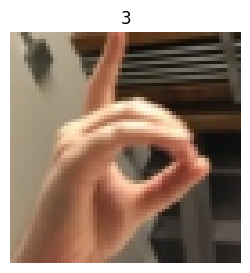

Characteristic vectors: 
[[13.193789  64.9311   ]
 [27.979805  55.992336 ]
 [36.47209   47.066093 ]
 [44.642807  42.1856   ]
 [51.21047   36.53802  ]
 [20.130096  27.885523 ]
 [25.359446  15.629011 ]
 [27.878025   7.5245256]
 [29.176321   0.4512332]
 [16.564844  27.910715 ]
 [33.579906  19.781147 ]
 [44.554928  25.124388 ]
 [49.48802   32.09329  ]
 [15.460174  30.941412 ]
 [32.373367  23.076754 ]
 [42.761368  28.179564 ]
 [47.596416  34.13946  ]
 [16.812778  36.06182  ]
 [29.177378  28.338041 ]
 [38.114826  28.389408 ]
 [43.834507  30.416348 ]]


In [95]:
# Sanity check
print("Dataset len:")
print(len(validated_test_dataset))

print("\nDataset classes:")
print(validated_test_dataset.classes)

print("\nRandom image from dataset:")
img, label, characteristic_vectors = validated_test_dataset[random.randint(0, len(validated_test_dataset)-1)]
image = img.permute(1, 2, 0).numpy()  # [C, H, W] -> [H, W, C]

# Denormalizing (there was normalization in transform)
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
image = image * std + mean
image = image.clip(0, 1)

plt.figure(figsize=(3,3))
plt.imshow(image)
plt.axis("off")
plt.title(label)
plt.show()

print("Characteristic vectors: ")
print(characteristic_vectors)


In [96]:
validated_test_dataset_loader = DataLoader(validated_test_dataset, 
                             batch_size=32, 
                             shuffle=False, 
                             num_workers=0)


In [97]:
criterion = nn.CrossEntropyLoss()
test_loss, test_accuracy = test_model(device, model, validated_test_dataset_loader, criterion)

Test Loss: 0.0045, Test Accuracy: 93.77%
